<a href="https://colab.research.google.com/github/MukulGhai/Sampling/blob/main/sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [3]:
df=pd.read_csv('/content/Creditcard_data.csv')

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 772 entries, 0 to 771
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    772 non-null    int64  
 1   V1      772 non-null    float64
 2   V2      772 non-null    float64
 3   V3      772 non-null    float64
 4   V4      772 non-null    float64
 5   V5      772 non-null    float64
 6   V6      772 non-null    float64
 7   V7      772 non-null    float64
 8   V8      772 non-null    float64
 9   V9      772 non-null    float64
 10  V10     772 non-null    float64
 11  V11     772 non-null    float64
 12  V12     772 non-null    float64
 13  V13     772 non-null    float64
 14  V14     772 non-null    float64
 15  V15     772 non-null    float64
 16  V16     772 non-null    float64
 17  V17     772 non-null    float64
 18  V18     772 non-null    float64
 19  V19     772 non-null    float64
 20  V20     772 non-null    float64
 21  V21     772 non-null    float64
 22  V2

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,772.000000,772.000000,772.000000,772.000000,772.000000,772.000000,772.000000,772.000000,772.000000,772.000000,...,772.000000,772.000000,772.000000,772.000000,772.000000,772.000000,772.000000,772.000000,772.000000,772.000000
mean,283.005181,-0.176963,0.217169,0.875172,0.285628,-0.005029,0.159081,0.123329,-0.057547,-0.030384,...,0.004888,-0.096995,-0.040344,-0.002501,0.114337,0.022782,0.023353,-0.017045,68.668290,0.011658
std,171.834196,1.294724,1.173401,1.031878,1.258758,1.098143,1.225682,0.852075,0.830144,0.878183,...,0.609335,0.607228,0.358724,0.621507,0.429667,0.484227,0.300934,0.278332,197.838269,0.107411
min,0.000000,-6.093248,-12.114213,-5.694973,-4.657545,-6.631951,-3.498447,-4.925568,-7.494658,-2.770089,...,-4.134608,-2.776923,-3.553381,-1.867208,-1.389079,-1.243924,-2.377933,-2.735623,0.000000,0.000000
25%,126.500000,-0.896416,-0.174684,0.308677,-0.460058,-0.534567,-0.630717,-0.296289,-0.167880,-0.517068,...,-0.213746,-0.525289,-0.176915,-0.379766,-0.166227,-0.313631,-0.047868,-0.033083,5.987500,0.000000
50%,282.000000,-0.382618,0.285843,0.905435,0.395919,-0.116612,-0.109581,0.116329,0.034755,-0.082270,...,-0.075802,-0.076551,-0.048353,0.091886,0.143723,-0.026414,0.023199,0.021034,16.665000,0.000000
75%,432.000000,1.110739,0.885745,1.532969,1.117559,0.452818,0.482972,0.575390,0.252395,0.412261,...,0.095149,0.307438,0.070085,0.426339,0.425798,0.260408,0.112199,0.087023,55.527500,0.000000
max,581.000000,1.586093,5.267376,3.772857,4.075817,7.672544,5.122103,4.808426,2.134599,5.459274,...,5.273420,1.574750,3.150413,1.215279,1.136720,3.087444,2.490503,1.575380,3828.040000,1.000000


In [7]:
df['Class'].nunique()

2

In [8]:
df['Class'].value_counts()

,count
Class,
0,763
1,9


In [9]:
Y=df['Class']
X=df.drop(columns=['Class'])

In [10]:
## oversample
class_0=df[df['Class']==0]
class_1=df[df['Class']==1]
class_1_over=class_1.sample(n=len(class_0),random_state=21,replace=True)

In [ ]:
df=pd.concat([class_1_over,class_0])
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
766,574,1.257719,0.364739,0.306923,0.690638,-0.357792,-1.067481,0.094272,-0.210300,0.014455,...,-0.286856,-0.820658,0.127663,0.343128,0.221120,0.094391,-0.022189,0.030944,1.29,1
623,472,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1
766,574,1.257719,0.364739,0.306923,0.690638,-0.357792,-1.067481,0.094272,-0.210300,0.014455,...,-0.286856,-0.820658,0.127663,0.343128,0.221120,0.094391,-0.022189,0.030944,1.29,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,575,-0.572263,0.731748,1.541254,0.150506,1.108974,0.372152,1.084879,-0.146329,-0.274447,...,-0.143508,-0.107582,-0.418263,-0.731029,0.877525,-0.364150,-0.177509,-0.256545,26.72,0
768,579,-1.296845,-0.511605,2.404726,-0.310762,-0.319551,-0.542842,-0.173310,0.260423,-1.202688,...,-0.071270,-0.161175,0.088496,0.285390,0.281069,-0.370130,0.043410,0.092318,80.00,0
769,579,1.214170,0.210481,0.484651,0.479768,-0.261955,-0.527039,0.021782,-0.106888,-0.037631,...,-0.224292,-0.594609,0.159877,0.091873,0.140964,0.227406,-0.017389,0.016030,5.98,0
770,580,1.267030,-0.071114,0.037680,0.512683,0.242392,0.705212,-0.226582,0.109483,0.657565,...,-0.164468,-0.177225,-0.222918,-1.245505,0.678360,0.525059,0.002920,-0.003333,12.36,0


In [11]:
df = df.sample(frac=1).reset_index(drop=True)
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,206,-0.370563,0.599810,0.216683,-0.513093,2.697143,3.882795,0.295545,0.850059,-0.297189,...,-0.147920,-0.176214,-0.120575,1.042297,-0.391705,0.675405,0.163595,-0.004997,10.27,0
1,256,-0.471796,0.523169,1.948967,0.995503,0.379069,-0.577466,0.521413,-0.128940,-0.704962,...,-0.099422,-0.287139,0.151288,0.490367,-0.725252,-0.741834,0.004784,-0.045977,18.45,0
2,298,1.218417,0.077792,0.533944,0.843849,-0.536022,-0.702281,0.006656,-0.153411,0.421584,...,-0.224558,-0.466722,0.003663,0.438026,0.460760,0.267056,-0.021916,0.014812,13.99,0
3,154,1.315601,0.413148,-0.018953,0.487834,0.132331,-0.574307,0.146563,-0.215923,-0.080276,...,-0.329567,-0.891188,0.011352,-0.477579,0.365667,0.143254,-0.016757,0.024640,1.98,0
4,375,-0.837689,0.777698,1.841252,3.056892,0.303627,0.615335,0.531504,-0.081955,-0.522527,...,-0.070069,0.556788,0.217681,0.100721,-0.332479,0.252526,0.138865,-0.085152,29.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,12,-0.752417,0.345485,2.057323,-1.468643,-1.158394,-0.077850,-0.608581,0.003603,-0.436167,...,0.499625,1.353650,-0.256573,-0.065084,-0.039124,-0.087086,-0.180998,0.129394,15.99,0
768,249,-0.788406,1.125172,0.934213,1.155815,-0.028518,0.489476,0.067377,0.775357,-0.507977,...,0.026451,0.204265,-0.128794,-0.319663,-0.095104,-0.214423,0.291529,0.120686,13.28,0
769,460,-2.264656,-0.707192,1.080243,-4.657545,-0.157183,-0.345406,0.595042,-0.386704,2.211141,...,-0.632027,0.222079,-0.189412,-0.332603,0.050197,-1.168870,-0.208793,-0.486754,50.78,0
770,290,-0.487234,0.505825,0.880670,0.972986,0.823367,0.287738,0.725039,0.021040,-0.268138,...,-0.052209,-0.129567,-0.177153,-1.004116,0.169317,-0.234252,0.129244,0.139251,67.36,0


<Axes: title={'center': 'count (target)'}, xlabel='Class'>

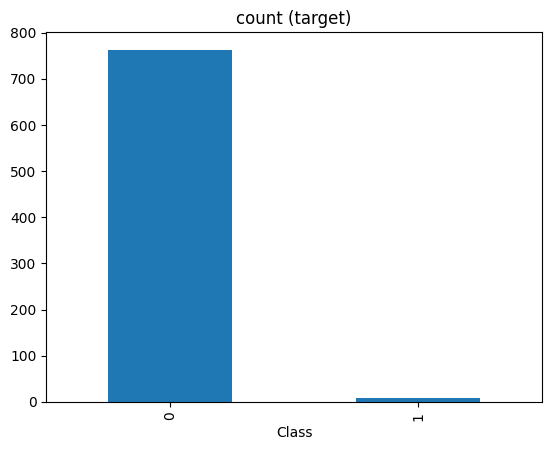

In [12]:
df['Class'].value_counts().plot(kind='bar', title='count (target)')

In [13]:
def simple(X, Y):
    df = X.copy()
    df['Class'] = Y.values
    s = df.sample(frac=0.7, random_state=42)
    return s.drop(columns=['Class']), s['Class']


In [14]:
def stratified_sampling(X, Y):
    X_s, _, y_s, _ = train_test_split(
        X, Y, train_size=0.7, stratify=Y, random_state=42
    )
    return X_s, y_s



In [15]:
def systematic(X, Y):
    df = X.copy()
    df['Class'] = Y.values

    n = len(df)
    sample_size = int(0.7 * n)
    step = n // sample_size

    indices = list(range(0, n, step))[:sample_size]
    s = df.iloc[indices]

    return s.drop(columns=['Class']), s['Class']



In [16]:
def cluster_sampling(X, Y):
    df = X.copy()
    df['Class'] = Y.values
    df['cluster'] = pd.qcut(df.index, 5, labels=False)

    chosen = np.random.choice(df['cluster'].unique())
    s = df[df['cluster'] == chosen]

    return s.drop(columns=['Class', 'cluster']), s['Class']


In [17]:
def bootstrap(X, Y):
    df = X.copy()
    df['Class'] = Y.values

    n = len(df)
    indices = np.random.choice(n, size=n, replace=True)
    s = df.iloc[indices]

    return s.drop(columns=['Class']), s['Class']


In [18]:
models = {
    "M1": LogisticRegression(max_iter=1000),
    "M2": DecisionTreeClassifier(),
    "M3": RandomForestClassifier(),
    "M4": GaussianNB(),
    "M5": SVC()
}


In [19]:
sampling_methods = {
    "Sampling1": simple,
    "Sampling2": systematic,
    "Sampling3": stratified_sampling,
    "Sampling4": cluster_sampling,
    "Sampling5": bootstrap
}


In [20]:
models = {
    "M1": LogisticRegression(max_iter=1000),
    "M2": DecisionTreeClassifier(),
    "M3": RandomForestClassifier(),
    "M4": GaussianNB(),
    "M5": SVC()
}

In [21]:
results = pd.DataFrame(
    index=models.keys(),
    columns=sampling_methods.keys()
)


In [22]:
for s_name, s_func in sampling_methods.items():
    X_s, y_s = s_func(X, Y)

    X_train, X_test, y_train, y_test = train_test_split(
        X_s, y_s, test_size=0.3, random_state=42
    )

    for m_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred) * 100
        results.loc[m_name, s_name] = round(acc, 2)

print("\nAccuracy Table (%)")
print(results)



Accuracy Table (%)
   Sampling1 Sampling2 Sampling3 Sampling4 Sampling5
M1     99.38     98.77     98.15     95.74     99.14
M2      96.3     98.15     97.53     93.62     96.55
M3     99.38     98.77     98.77     95.74     99.14
M4     95.68     98.77     95.06     95.74     98.71
M5     99.38     98.77     98.77     95.74     98.71


In [23]:
best_combo = results.stack().idxmax()
best_value = results.max().max()

best_model_key = best_combo[0]
best_sampling = best_combo[1]

print("\nBest Combination:")
print("Model ID:", best_model_key)
print("Model Name:", models[best_model_key])

if best_sampling == "Sampling1":
    print("Sampling Used: Simple Random Sampling")
elif best_sampling == "Sampling2":
    print("Sampling Used: Systematic Sampling")
elif best_sampling == "Sampling3":
    print("Sampling Used: Stratified Sampling")
elif best_sampling == "Sampling4":
    print("Sampling Used: Cluster Sampling")
elif best_sampling == "Sampling5":
    print("Sampling Used: Bootstrap Sampling")

print("Accuracy:", round(best_value, 2))



Best Combination:
Model ID: M1
Model Name: LogisticRegression(max_iter=1000)
Sampling Used: Simple Random Sampling
Accuracy: 99.38
